In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:99% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

In [3]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [8]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는?0
화씨온도는  32.0


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링 처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로 학습시킴)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)
## 2.1 노이즈가 없는 데이터로 실습

In [3]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [4]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타켓변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [5]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는', scaled_data_C)
print('종속변수는', scaled_data_F)

독립변수는 [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는 [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.724

In [7]:
# 3. 모델 구성하기(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
                input_shape=(1,) # 입력(독립)변수의 shape
                     ))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


- 회귀분석 오차함수 :
    MSE(오차제곱평균), RMSE(루트를 취하기때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [15]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
                # 손실함수     옵티마저이저          평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [18]:
# 학습 전 예측
model.predict(np.array([[0],
                       [0.01]]))

1/1 [==============================] - 0s 185ms/step


array([[ 0.       ],
       [-0.0132977]], dtype=float32)

In [19]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [20]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                #   독립변수      타겟변수(종속)     학습횟수    학습시출력여부

Epoch 1/1000
4/4 - 1s - loss: 4.2912 - mae: 1.8647 - 590ms/epoch - 147ms/step
Epoch 2/1000
4/4 - 0s - loss: 4.2430 - mae: 1.8528 - 11ms/epoch - 3ms/step
Epoch 3/1000
4/4 - 0s - loss: 4.2129 - mae: 1.8452 - 8ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 4.1880 - mae: 1.8390 - 7ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 4.1606 - mae: 1.8322 - 9ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 4.1354 - mae: 1.8259 - 9ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 4.1111 - mae: 1.8198 - 7ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 4.0874 - mae: 1.8139 - 8ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 4.0607 - mae: 1.8072 - 6ms/epoch - 1ms/step
Epoch 10/1000
4/4 - 0s - loss: 4.0399 - mae: 1.8018 - 8ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 4.0172 - mae: 1.7961 - 8ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 3.9971 - mae: 1.7909 - 7ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 3.9744 - mae: 1.7851 - 7ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - loss

4/4 - 0s - loss: 2.0947 - mae: 1.2259 - 6ms/epoch - 1ms/step
Epoch 111/1000
4/4 - 0s - loss: 2.0785 - mae: 1.2202 - 5ms/epoch - 1ms/step
Epoch 112/1000
4/4 - 0s - loss: 2.0640 - mae: 1.2152 - 7ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 2.0499 - mae: 1.2105 - 6ms/epoch - 1ms/step
Epoch 114/1000
4/4 - 0s - loss: 2.0333 - mae: 1.2048 - 6ms/epoch - 1ms/step
Epoch 115/1000
4/4 - 0s - loss: 2.0160 - mae: 1.1988 - 5ms/epoch - 1ms/step
Epoch 116/1000
4/4 - 0s - loss: 2.0004 - mae: 1.1935 - 6ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.9847 - mae: 1.1879 - 6ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.9700 - mae: 1.1830 - 6ms/epoch - 1ms/step
Epoch 119/1000
4/4 - 0s - loss: 1.9539 - mae: 1.1773 - 6ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.9393 - mae: 1.1722 - 9ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 1.9223 - mae: 1.1663 - 6ms/epoch - 1ms/step
Epoch 122/1000
4/4 - 0s - loss: 1.9068 - mae: 1.1609 - 6ms/epoch - 1ms/step
Epoch 123/1000
4/4 - 0s - l

Epoch 218/1000
4/4 - 0s - loss: 0.7979 - mae: 0.7301 - 6ms/epoch - 1ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.7903 - mae: 0.7267 - 5ms/epoch - 1ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.7837 - mae: 0.7237 - 6ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.7768 - mae: 0.7207 - 6ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.7695 - mae: 0.7176 - 5ms/epoch - 1ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.7618 - mae: 0.7140 - 6ms/epoch - 1ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.7533 - mae: 0.7100 - 6ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.7452 - mae: 0.7065 - 7ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.7373 - mae: 0.7029 - 6ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.7294 - mae: 0.6993 - 6ms/epoch - 1ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.7226 - mae: 0.6961 - 5ms/epoch - 1ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.7164 - mae: 0.6934 - 7ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.7080 - mae: 0.6894 - 8ms/epoch - 2ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.3031 - mae: 0.4756 - 7ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.3018 - mae: 0.4746 - 8ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.3002 - mae: 0.4736 - 14ms/epoch - 3ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.2987 - mae: 0.4724 - 7ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.2974 - mae: 0.4715 - 7ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.2962 - mae: 0.4706 - 7ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.2945 - mae: 0.4693 - 7ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.2929 - mae: 0.4682 - 6ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.2912 - mae: 0.4669 - 9ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.2902 - mae: 0.4660 - 7ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.2892 - mae: 0.4654 - 7ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.2877 - mae: 0.4642 - 7ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.2867 - mae: 0.4634 - 9ms/epoch - 2ms/step
Epoch 339/1

Epoch 434/1000
4/4 - 0s - loss: 0.1961 - mae: 0.3826 - 7ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.1954 - mae: 0.3819 - 6ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.1947 - mae: 0.3813 - 7ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.1939 - mae: 0.3804 - 6ms/epoch - 1ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.1933 - mae: 0.3799 - 6ms/epoch - 1ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.1926 - mae: 0.3791 - 7ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.1920 - mae: 0.3785 - 6ms/epoch - 1ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.1913 - mae: 0.3778 - 7ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.1904 - mae: 0.3769 - 8ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.1897 - mae: 0.3763 - 6ms/epoch - 1ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.1889 - mae: 0.3754 - 7ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.1883 - mae: 0.3749 - 7ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.1876 - mae: 0.3741 - 5ms/epoch - 1ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.1145 - mae: 0.2923 - 7ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1140 - mae: 0.2916 - 6ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.1133 - mae: 0.2907 - 6ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.1127 - mae: 0.2900 - 7ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.1121 - mae: 0.2892 - 7ms/epoch - 2ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.1114 - mae: 0.2883 - 7ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.1109 - mae: 0.2875 - 6ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.1103 - mae: 0.2866 - 8ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.1096 - mae: 0.2857 - 7ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.1089 - mae: 0.2848 - 7ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.1083 - mae: 0.2840 - 8ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.1076 - mae: 0.2831 - 6ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.1069 - mae: 0.2823 - 7ms/epoch - 2ms/step
Epoch 555/10

Epoch 650/1000
4/4 - 0s - loss: 0.0543 - mae: 0.2014 - 6ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0539 - mae: 0.2006 - 6ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0535 - mae: 0.1996 - 6ms/epoch - 1ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0530 - mae: 0.1988 - 7ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0526 - mae: 0.1980 - 6ms/epoch - 1ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0522 - mae: 0.1973 - 6ms/epoch - 1ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0516 - mae: 0.1963 - 6ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0513 - mae: 0.1957 - 5ms/epoch - 1ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0508 - mae: 0.1947 - 6ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0503 - mae: 0.1938 - 6ms/epoch - 1ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0498 - mae: 0.1928 - 6ms/epoch - 1ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0494 - mae: 0.1921 - 5ms/epoch - 1ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0490 - mae: 0.1912 - 6ms/epoch - 2ms/step
Epoch 663/10

Epoch 758/1000
4/4 - 0s - loss: 0.0169 - mae: 0.1123 - 5ms/epoch - 1ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0167 - mae: 0.1114 - 6ms/epoch - 1ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0163 - mae: 0.1104 - 5ms/epoch - 1ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0161 - mae: 0.1094 - 6ms/epoch - 1ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0158 - mae: 0.1088 - 6ms/epoch - 1ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0155 - mae: 0.1077 - 6ms/epoch - 1ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0153 - mae: 0.1068 - 7ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0151 - mae: 0.1062 - 7ms/epoch - 2ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0148 - mae: 0.1052 - 6ms/epoch - 1ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0146 - mae: 0.1044 - 6ms/epoch - 2ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0144 - mae: 0.1038 - 5ms/epoch - 1ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0142 - mae: 0.1029 - 5ms/epoch - 1ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0140 - mae: 0.1021 - 6ms/epoch - 2ms/step
Epoch 771/10

Epoch 866/1000
4/4 - 0s - loss: 8.9520e-04 - mae: 0.0258 - 6ms/epoch - 1ms/step
Epoch 867/1000
4/4 - 0s - loss: 8.3662e-04 - mae: 0.0249 - 6ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 7.8020e-04 - mae: 0.0242 - 6ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 7.2564e-04 - mae: 0.0233 - 7ms/epoch - 2ms/step
Epoch 870/1000
4/4 - 0s - loss: 6.8011e-04 - mae: 0.0225 - 6ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 6.3789e-04 - mae: 0.0217 - 7ms/epoch - 2ms/step
Epoch 872/1000
4/4 - 0s - loss: 5.8272e-04 - mae: 0.0208 - 9ms/epoch - 2ms/step
Epoch 873/1000
4/4 - 0s - loss: 5.3574e-04 - mae: 0.0200 - 8ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 4.9811e-04 - mae: 0.0193 - 7ms/epoch - 2ms/step
Epoch 875/1000
4/4 - 0s - loss: 4.6209e-04 - mae: 0.0184 - 6ms/epoch - 2ms/step
Epoch 876/1000
4/4 - 0s - loss: 4.2118e-04 - mae: 0.0177 - 8ms/epoch - 2ms/step
Epoch 877/1000
4/4 - 0s - loss: 3.8008e-04 - mae: 0.0168 - 8ms/epoch - 2ms/step
Epoch 878/1000
4/4 - 0s - loss: 3.4189e-

Epoch 966/1000
4/4 - 0s - loss: 1.5772e-07 - mae: 3.8377e-04 - 8ms/epoch - 2ms/step
Epoch 967/1000
4/4 - 0s - loss: 2.6632e-07 - mae: 4.9605e-04 - 6ms/epoch - 2ms/step
Epoch 968/1000
4/4 - 0s - loss: 9.9556e-07 - mae: 9.7754e-04 - 6ms/epoch - 2ms/step
Epoch 969/1000
4/4 - 0s - loss: 1.0354e-06 - mae: 9.2771e-04 - 6ms/epoch - 1ms/step
Epoch 970/1000
4/4 - 0s - loss: 7.4669e-08 - mae: 2.6645e-04 - 6ms/epoch - 1ms/step
Epoch 971/1000
4/4 - 0s - loss: 1.4599e-07 - mae: 3.6899e-04 - 6ms/epoch - 2ms/step
Epoch 972/1000
4/4 - 0s - loss: 1.2907e-06 - mae: 0.0011 - 5ms/epoch - 1ms/step
Epoch 973/1000
4/4 - 0s - loss: 2.3636e-07 - mae: 4.7849e-04 - 6ms/epoch - 2ms/step
Epoch 974/1000
4/4 - 0s - loss: 6.6796e-07 - mae: 8.0151e-04 - 6ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 5.8358e-07 - mae: 7.5084e-04 - 6ms/epoch - 2ms/step
Epoch 976/1000
4/4 - 0s - loss: 4.6676e-07 - mae: 6.7011e-04 - 8ms/epoch - 2ms/step
Epoch 977/1000
4/4 - 0s - loss: 7.1228e-07 - mae: 8.2720e-04 - 5ms/epoch - 1ms/s

In [22]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

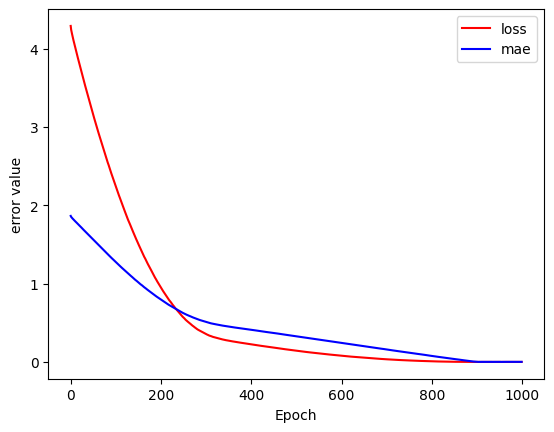

In [26]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [27]:
# 모델 사용
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

1/1 [==============================] - 0s 30ms/step


array([[0.32051623],
       [0.33852118],
       [0.35652614]], dtype=float32)

In [28]:
model.save('model/after_learning.h5')

In [7]:
# 모델 load
from tensorflow.keras.models import load_model
model = load_model('model/after_learning.h5')

In [11]:
y_hat = model.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 # mean square error(mse)

4/4 [==============================] - 0s 3ms/step


6.004483347731707e-07

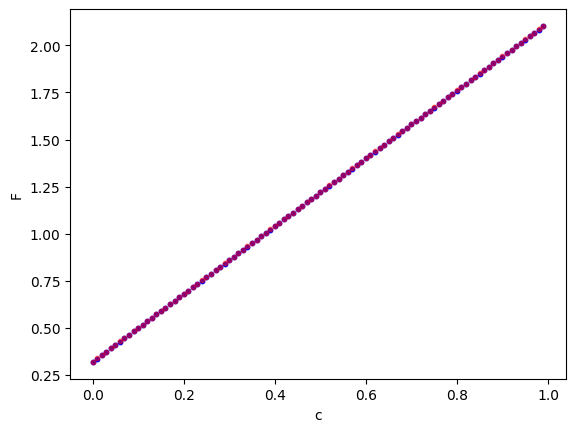

In [16]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', s=10)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', s=10, alpha=0.5)
plt.xlabel('c')
plt.ylabel('F')
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [23]:
# 평균이 0이고 표준편차가 1인 넘파이 배열을 생성(size만큼)
np.random.seed(707)
noise = np.random.normal(0, scale=0.1, size=100)
noised_scaled_data_F = noise + scaled_data_F
noised_scaled_data_F

array([0.27500034, 0.20410134, 0.39498826, 0.27117424, 0.26897164,
       0.35314388, 0.4496784 , 0.42612159, 0.49409646, 0.45740286,
       0.31574183, 0.67996337, 0.46117139, 0.66152189, 0.45319086,
       0.4519712 , 0.73018132, 0.54170904, 0.68386841, 0.75022628,
       0.65735179, 0.76512782, 0.57019861, 0.79130977, 0.62965251,
       0.60058611, 0.81087191, 0.79345666, 0.90825121, 0.80020546,
       0.8489619 , 0.72808603, 0.98336163, 0.78173322, 0.8212351 ,
       1.05542797, 0.86566002, 0.99728791, 1.14628604, 0.93021808,
       0.91091956, 1.20887357, 0.89807223, 1.08124513, 0.95949964,
       1.24417872, 1.47029141, 0.89345844, 1.24009232, 1.26965718,
       1.39203371, 1.20086793, 1.17335862, 1.18484202, 1.26527807,
       1.25914114, 1.25582658, 1.46684352, 1.42267387, 1.38347091,
       1.34554506, 1.45325705, 1.58244673, 1.31622328, 1.38397926,
       1.53624202, 1.36919068, 1.51482044, 1.6480895 , 1.69886349,
       1.60323679, 1.68203012, 1.53758531, 1.57779451, 1.73967

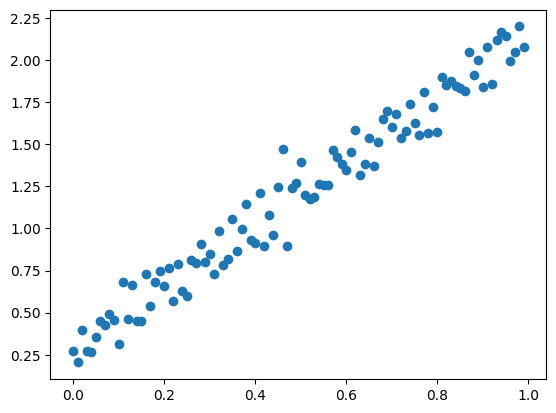

In [25]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [27]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model2 = Sequential()
model2.add(Dense(units=1, input_shape=(1, ))) # units출력갯수, input_shape입력 shape
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
                # 손실함수       옵티마이저            평가지표
print(model2.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


In [28]:
# 5. 학습시키기
hist2 = model2.fit(scaled_data_C,
                  noised_scaled_data_F,
                  epochs=1000,
                  verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 4ms/step - loss: 1.5990 - mae: 1.1523
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5710 - mae: 1.1410
Epoch 3/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5503 - mae: 1.1326
Epoch 4/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5341 - mae: 1.1260
Epoch 5/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5169 - mae: 1.1189
Epoch 6/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.5025 - mae: 1.1130
Epoch 7/1000
4/4 [==============================] - 0s 6ms/step - loss: 1.4875 - mae: 1.1068
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.4723 - mae: 1.1004
Epoch 9/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.4577 - mae: 1.0943
Epoch 10/1000
4/4 [==============================] - 0s 3ms/step - loss: 1.4442 - mae: 1.0886
Epoch 11/1000
4/4 [==============================] - 0s 2ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 0.5850 - mae: 0.6464
Epoch 89/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5776 - mae: 0.6417
Epoch 90/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5702 - mae: 0.6365
Epoch 91/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5625 - mae: 0.6318
Epoch 92/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.5542 - mae: 0.6262
Epoch 93/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5466 - mae: 0.6213
Epoch 94/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5381 - mae: 0.6155
Epoch 95/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5298 - mae: 0.6100
Epoch 96/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.5220 - mae: 0.6046
Epoch 97/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5151 - mae: 0.5999
Epoch 98/1000
4/4 [==============================] - 0s 2ms/step - loss: 0

4/4 [==============================] - 0s 2ms/step - loss: 0.1382 - mae: 0.3123
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1360 - mae: 0.3104
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1337 - mae: 0.3084
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1315 - mae: 0.3062
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1291 - mae: 0.3040
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1273 - mae: 0.3023
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1254 - mae: 0.3005
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1236 - mae: 0.2986
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1218 - mae: 0.2971
Epoch 183/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.1205 - mae: 0.2956
Epoch 184/1000
4/4 [==============================] - 0s 1ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0668 - mae: 0.2198
Epoch 261/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0663 - mae: 0.2188
Epoch 262/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0659 - mae: 0.2182
Epoch 263/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0656 - mae: 0.2177
Epoch 264/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0652 - mae: 0.2170
Epoch 265/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0648 - mae: 0.2163
Epoch 266/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0643 - mae: 0.2153
Epoch 267/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0639 - mae: 0.2147
Epoch 268/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0636 - mae: 0.2142
Epoch 269/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0633 - mae: 0.2136
Epoch 270/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0370 - mae: 0.1622
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0368 - mae: 0.1615
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0365 - mae: 0.1609
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0362 - mae: 0.1603
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0359 - mae: 0.1596
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0356 - mae: 0.1588
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0353 - mae: 0.1582
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0350 - mae: 0.1575
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0348 - mae: 0.1570
Epoch 355/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0345 - mae: 0.1562
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

...

4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0885
Epoch 605/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0111 - mae: 0.0885
Epoch 606/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0883
Epoch 607/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0883
Epoch 608/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0883
Epoch 609/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0883
Epoch 610/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0111 - mae: 0.0881
Epoch 611/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0880
Epoch 612/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0111 - mae: 0.0882
Epoch 613/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0111 - mae: 0.0882
Epoch 614/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 698/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0879
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 777/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 778/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 779/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 780/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 781/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 782/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0876
Epoch 783/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 784/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 785/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 786/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 865/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0878
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 949/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 950/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0877
Epoch 951/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 952/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 953/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 954/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 955/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0877
Epoch 956/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 957/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 958/1000
4/4 [==============================] - 0s 2ms/step

In [30]:
hist2.history.keys()

dict_keys(['loss', 'mae'])

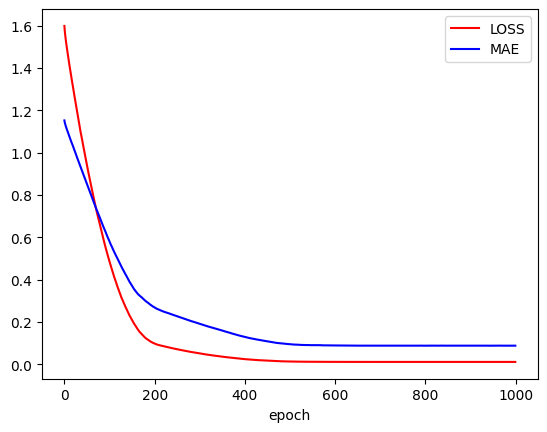

In [33]:
plt.plot(hist2.history['loss'], 'r', label='LOSS')
plt.plot(hist2.history['mae'], 'b', label='MAE')
plt.legend()
plt.xlabel('epoch')
plt.show()

In [35]:
y_hat = model2.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, noised_scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 #mse

4/4 [==============================] - 0s 2ms/step


0.010948543965245718

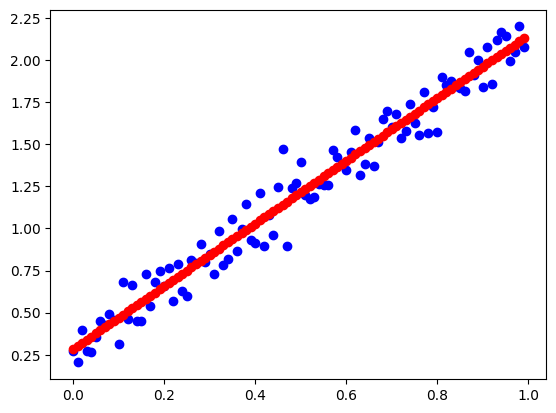

In [36]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='b')
plt.scatter(x=scaled_data_C, y=y_hat, c='r')